# Image Generation GANs, Diffusion Models & Beyond

## Overview
Generative models learn the data distribution $p(x)$ and can sample new realistic images. Three dominant paradigms:
1. **GANs** adversarial training, fast sampling, mode collapse risk
2. **VAEs** latent space interpolation, blurry outputs
3. **Diffusion Models** highest quality, slower sampling

---

## Generative Adversarial Networks (GANs)

**Minimax game** between Generator G and Discriminator D:
$$\min_G \max_D V(D,G) = \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1-D(G(z)))]$$

At optimum: $D^*(x) = \frac{p_{data}(x)}{p_{data}(x) + p_g(x)} = \frac{1}{2}$

**Training issues**: vanishing gradients for G when D is too good. Solution: use $\max_G \mathbb{E}[\log D(G(z))]$ (non-saturating GAN).

### GAN Variants

| Model | Year | Key Innovation |
|-------|------|----------------|
| GAN | 2014 | Original |
| DCGAN | 2016 | CNN-based, batch norm, conv-transpose |
| WGAN | 2017 | Wasserstein distance, stable training |
| WGAN-GP | 2017 | Gradient penalty instead of clipping |
| cGAN | 2014 | Conditional generation with class labels |
| Pix2Pix | 2017 | Image-to-image translation |
| CycleGAN | 2017 | Unpaired image translation |
| PGGAN | 2018 | Progressive growing |
| StyleGAN | 2019 | Style-based generator |
| StyleGAN2 | 2020 | Removes artifacts, weight demodulation |
| BigGAN | 2019 | Large-scale class-conditional |
| GigaGAN | 2023 | Text-conditioned, 1B params |

**Wasserstein distance** (Earth Mover's Distance):
$$W(P_r, P_g) = \inf_{\gamma \in \Pi(P_r,P_g)} \mathbb{E}_{(x,y)\sim\gamma}[||x-y||]$$

**WGAN loss** (with 1-Lipschitz constraint on critic $f$):
$$\min_G \max_{||f||_L \leq 1} \mathbb{E}_{x\sim P_r}[f(x)] - \mathbb{E}_{z\sim p_z}[f(G(z))]$$

**Gradient Penalty** (WGAN-GP):
$$\mathcal{L}_{GP} = \lambda \mathbb{E}_{\hat{x}\sim P_{\hat{x}}}[(||\nabla_{\hat{x}}D(\hat{x})||_2 - 1)^2]$$

---

## Diffusion Models

### DDPM (Denoising Diffusion Probabilistic Models, 2020)

**Forward process** (add noise over T steps):
$$q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{1-\beta_t}\, x_{t-1},\, \beta_t I)$$

Closed form at any $t$ (using $\alpha_t = 1-\beta_t$, $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$):
$$q(x_t | x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha}_t}\, x_0,\, (1-\bar{\alpha}_t)I)$$

So: $x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1-\bar{\alpha}_t}\, \epsilon$, where $\epsilon \sim \mathcal{N}(0,I)$.

**Reverse process** (learned denoising):
$$p_\theta(x_{t-1}|x_t) = \mathcal{N}(x_{t-1}; \mu_\theta(x_t,t),\, \Sigma_\theta(x_t,t))$$

**Training objective** (simplified predict noise $\epsilon$):
$$\mathcal{L}_{simple} = \mathbb{E}_{t, x_0, \epsilon}\left[||\epsilon - \epsilon_\theta(\sqrt{\bar{\alpha}_t}x_0 + \sqrt{1-\bar{\alpha}_t}\epsilon, t)||^2\right]$$

**Sampling** (reverse diffusion, T steps):
$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{1-\alpha_t}{\sqrt{1-\bar{\alpha}_t}}\epsilon_\theta(x_t,t)\right) + \sigma_t z$$

### DDIM Denoising Diffusion Implicit Models (2021)
Non-Markovian sampling process. Fewer steps (50 instead of 1000), deterministic:
$$x_{t-1} = \sqrt{\bar{\alpha}_{t-1}}\underbrace{\left(\frac{x_t - \sqrt{1-\bar{\alpha}_t}\epsilon_\theta}{\sqrt{\bar{\alpha}_t}}\right)}_{\text{predicted }x_0} + \sqrt{1-\bar{\alpha}_{t-1}-\sigma_t^2}\cdot\epsilon_\theta + \sigma_t\epsilon$$

### Stable Diffusion (Latent Diffusion)

Key insight: run diffusion in **latent space** (4× smaller), not pixel space.

Components:
1. **VAE encoder**: $\mathcal{E}(x) = z$ (compress 512×512×3 → 64×64×4)
2. **CLIP text encoder**: $\tau_\theta(y)$ encode text prompt
3. **U-Net denoiser**: $\epsilon_\theta(z_t, t, \tau_\theta(y))$ predict noise with cross-attention on text
4. **VAE decoder**: $\mathcal{D}(z_0)$ decode back to pixels

**Classifier-Free Guidance (CFG)**:
$$\tilde{\epsilon}_\theta(z_t, t, y) = \epsilon_\theta(z_t, t, \emptyset) + w\cdot(\epsilon_\theta(z_t, t, y) - \epsilon_\theta(z_t, t, \emptyset))$$

where $w > 1$ amplifies text conditioning ($w=7.5$ typical).

---

## Evaluation Metrics

**FID (Fréchet Inception Distance)**:
$$FID = ||\mu_r - \mu_g||^2 + \text{tr}(\Sigma_r + \Sigma_g - 2(\Sigma_r\Sigma_g)^{1/2})$$
Lower is better.

**IS (Inception Score)**:
$$IS = \exp(\mathbb{E}_x[D_{KL}(p(y|x) || p(y))])$$
Higher is better.

**CLIP Score** measures text-image alignment.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# DCGAN from Scratch
# ============================================================

class DCGenerator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3, features_g=64):
        super().__init__()
        # Project and reshape noise vector
        self.net = nn.Sequential(
            # z_dim x 1 x 1 -> features_g*16 x 4 x 4
            self._block(z_dim, features_g*16, 4, 1, 0),
            # -> features_g*8 x 8 x 8
            self._block(features_g*16, features_g*8, 4, 2, 1),
            # -> features_g*4 x 16 x 16
            self._block(features_g*8, features_g*4, 4, 2, 1),
            # -> features_g*2 x 32 x 32
            self._block(features_g*4, features_g*2, 4, 2, 1),
            # -> img_channels x 64 x 64
            nn.ConvTranspose2d(features_g*2, img_channels, 4, 2, 1),
            nn.Tanh(),
        )

    def _block(self, in_ch, out_ch, kernel, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, z):
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self, img_channels=3, features_d=64):
        super().__init__()
        self.net = nn.Sequential(
            # img_channels x 64 x 64 -> features_d x 32 x 32
            nn.Conv2d(img_channels, features_d, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            self._block(features_d,   features_d*2, 4, 2, 1),
            self._block(features_d*2, features_d*4, 4, 2, 1),
            self._block(features_d*4, features_d*8, 4, 2, 1),
            nn.Conv2d(features_d*8, 1, 4, 2, 0),  # -> 1 x 1 x 1
        )

    def _block(self, in_ch, out_ch, kernel, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )

    def forward(self, x):
        return self.net(x)


# Test
G = DCGenerator(z_dim=100)
D = DCDiscriminator()

z = torch.randn(4, 100, 1, 1)   # Batch of 4 noise vectors
fake_imgs = G(z)
disc_out  = D(fake_imgs)

print(f'Noise:          {z.shape}')
print(f'Generated imgs: {fake_imgs.shape}')   # (4, 3, 64, 64)
print(f'Discriminator:  {disc_out.shape}')    # (4, 1, 1, 1)
print(f'G params: {sum(p.numel() for p in G.parameters())/1e6:.2f}M')
print(f'D params: {sum(p.numel() for p in D.parameters())/1e6:.2f}M')

Noise:          torch.Size([4, 100, 1, 1])
Generated imgs: torch.Size([4, 3, 64, 64])
Discriminator:  torch.Size([4, 1, 1, 1])
G params: 12.66M
D params: 2.77M


In [3]:
# ============================================================
# GAN Training Loop
# ============================================================

def train_dcgan_step(G, D, real_imgs, z_dim, device,
                     opt_G, opt_D, criterion):
    """
    One training step for DCGAN.
    Returns: loss_D, loss_G
    """
    batch_size = real_imgs.size(0)
    real_imgs  = real_imgs.to(device)

    # ---- Train Discriminator ----
    opt_D.zero_grad()
    # Real images -> label 1
    label_real = torch.ones(batch_size, 1, 1, 1, device=device)
    out_real   = D(real_imgs)
    loss_real  = criterion(out_real, label_real)

    # Fake images -> label 0
    z = torch.randn(batch_size, z_dim, 1, 1, device=device)
    fake_imgs  = G(z).detach()  # Detach so G gradients aren't computed
    label_fake = torch.zeros(batch_size, 1, 1, 1, device=device)
    out_fake   = D(fake_imgs)
    loss_fake  = criterion(out_fake, label_fake)

    loss_D = (loss_real + loss_fake) / 2
    loss_D.backward()
    opt_D.step()

    # ---- Train Generator ----
    opt_G.zero_grad()
    z         = torch.randn(batch_size, z_dim, 1, 1, device=device)
    fake_imgs = G(z)
    # G wants D to output 1 for fake images (fool D)
    out_fake  = D(fake_imgs)
    loss_G    = criterion(out_fake, torch.ones_like(out_fake))
    loss_G.backward()
    opt_G.step()

    return loss_D.item(), loss_G.item()


print('DCGAN training step defined.')
print('Usage:')
print('  criterion = nn.BCEWithLogitsLoss()')
print('  opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))')
print('  opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))')

DCGAN training step defined.
Usage:
  criterion = nn.BCEWithLogitsLoss()
  opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
  opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))


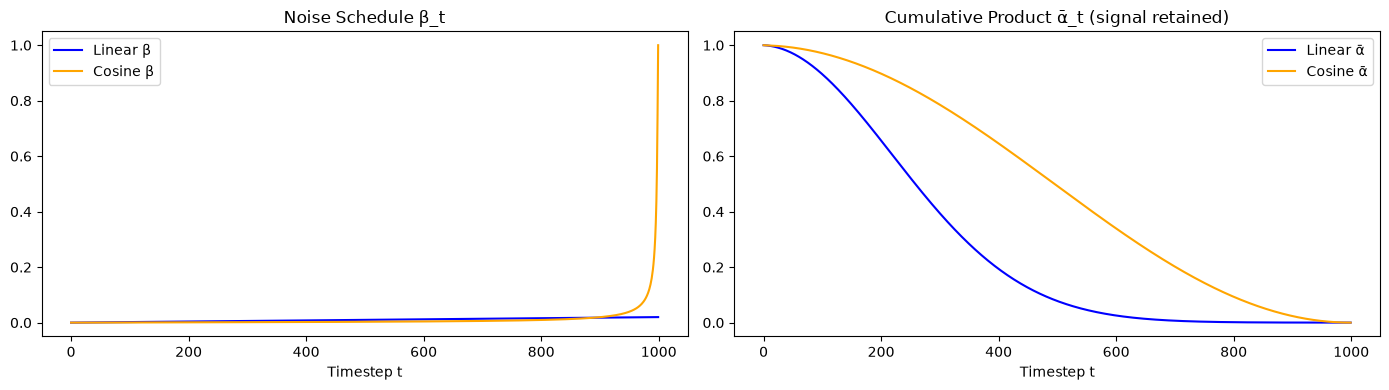

Linear ᾱ at T=1000: 0.000040 (almost pure noise)
Cosine ᾱ at T=1000: 0.000000


In [4]:
# ============================================================
# DDPM: Noise Schedule Visualization
# ============================================================

def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, timesteps)

def cosine_beta_schedule(timesteps, s=0.008):
    """Cosine schedule as proposed in "Improved DDPM" paper."""
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clamp(betas, 0.0001, 0.9999)


T = 1000
beta_linear = linear_beta_schedule(T)
beta_cosine = cosine_beta_schedule(T)

# Compute alphas
alpha_bar_linear = torch.cumprod(1 - beta_linear, dim=0)
alpha_bar_cosine = torch.cumprod(1 - beta_cosine, dim=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
t_range = range(T)

axes[0].plot(t_range, beta_linear.numpy(), label='Linear β', color='blue')
axes[0].plot(t_range, beta_cosine.numpy(), label='Cosine β', color='orange')
axes[0].set_title('Noise Schedule β_t'); axes[0].legend(); axes[0].set_xlabel('Timestep t')

axes[1].plot(t_range, alpha_bar_linear.numpy(), label='Linear ᾱ', color='blue')
axes[1].plot(t_range, alpha_bar_cosine.numpy(), label='Cosine ᾱ', color='orange')
axes[1].set_title('Cumulative Product ᾱ_t (signal retained)'); axes[1].legend()
axes[1].set_xlabel('Timestep t')

plt.tight_layout(); plt.show()
print(f'Linear ᾱ at T=1000: {alpha_bar_linear[-1]:.6f} (almost pure noise)')
print(f'Cosine ᾱ at T=1000: {alpha_bar_cosine[-1]:.6f}')

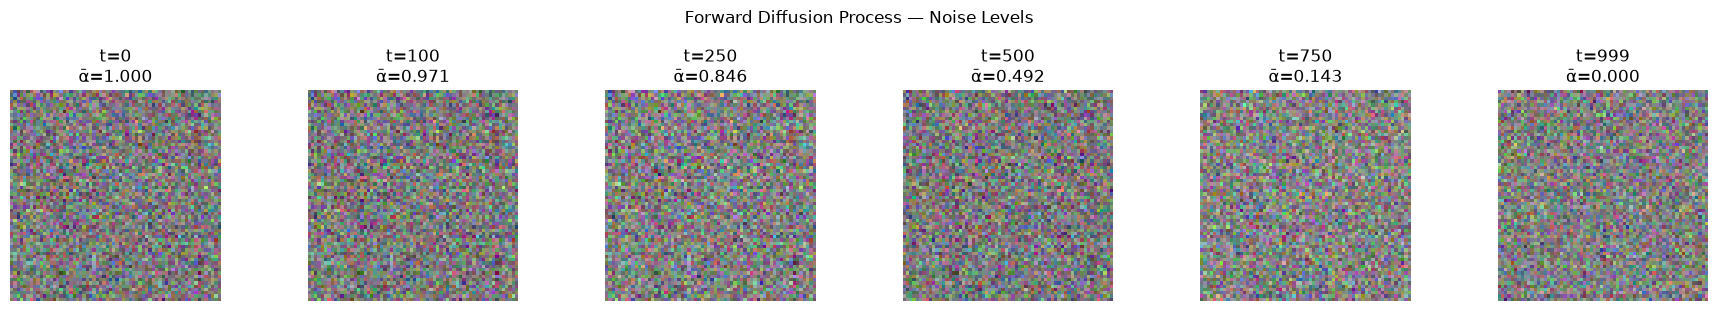

In [5]:
# ============================================================
# DDPM Forward Process Add Noise
# ============================================================

class DDPMForward:
    def __init__(self, timesteps=1000, schedule='cosine'):
        self.T = timesteps
        if schedule == 'linear':
            self.betas = linear_beta_schedule(timesteps)
        else:
            self.betas = cosine_beta_schedule(timesteps)

        self.alphas      = 1. - self.betas
        self.alpha_bar   = torch.cumprod(self.alphas, dim=0)
        self.sqrt_ab     = torch.sqrt(self.alpha_bar)
        self.sqrt_1m_ab  = torch.sqrt(1. - self.alpha_bar)

    def add_noise(self, x0, t, noise=None):
        """Add noise to x0 at timestep t using closed-form formula."""
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_ab = self.sqrt_ab[t].reshape(-1, 1, 1, 1)
        sqrt_1m = self.sqrt_1m_ab[t].reshape(-1, 1, 1, 1)
        return sqrt_ab * x0 + sqrt_1m * noise, noise


ddpm = DDPMForward(1000, 'cosine')

# Visualize forward diffusion on a synthetic image
x0 = torch.randn(1, 3, 64, 64)  # Synthetic image
timesteps_viz = [0, 100, 250, 500, 750, 999]

fig, axes = plt.subplots(1, len(timesteps_viz), figsize=(18, 3))
for ax, t in zip(axes, timesteps_viz):
    t_tensor = torch.tensor([t])
    xt, _ = ddpm.add_noise(x0, t_tensor)
    img_np = xt[0].permute(1,2,0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    ax.imshow(np.clip(img_np, 0, 1))
    ax.set_title(f't={t}\nᾱ={ddpm.alpha_bar[t]:.3f}')
    ax.axis('off')
plt.suptitle('Forward Diffusion Process Noise Levels', y=1.02)
plt.tight_layout(); plt.show()

In [6]:
# ============================================================
# Stable Diffusion with Diffusers Text-to-Image
# ============================================================
# pip install diffusers transformers accelerate

stable_diffusion_code = '''
from diffusers import StableDiffusionPipeline, DiffusionPipeline
from diffusers import StableDiffusionXLPipeline, AutoPipelineForText2Image
import torch

# ---- Stable Diffusion v1.5 ----
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

image = pipe(
    prompt="A majestic lion in the savanna, golden hour, photorealistic",
    negative_prompt="blurry, low quality, cartoon",
    num_inference_steps=30,    # DDIM steps
    guidance_scale=7.5,        # CFG scale
    width=512, height=512,
    generator=torch.manual_seed(42),
).images[0]
image.save("lion.png")

# ---- Stable Diffusion XL ----
pipe_xl = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16, use_safetensors=True
).to("cuda")

# ---- FLUX (state of art 2024) ----
pipe_flux = DiffusionPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-schnell",
    torch_dtype=torch.bfloat16
).to("cuda")

# ---- ControlNet ----
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
from diffusers.utils import load_image
import cv2
import numpy as np

controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny",
    torch_dtype=torch.float16
)
pipe_cn = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

# Generate canny edge map from input image
image = np.array(load_image("input.jpg"))
canny_image = cv2.Canny(image, 100, 200)
canny_image = Image.fromarray(canny_image)

result = pipe_cn(
    prompt="A beautiful portrait, professional photography",
    image=canny_image,
    num_inference_steps=20,
).images[0]

# ---- Image-to-Image ----
from diffusers import StableDiffusionImg2ImgPipeline
pipe_i2i = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

result = pipe_i2i(
    prompt="a dog in the style of Van Gogh",
    image=init_image,
    strength=0.75,     # How much to change (0=no change, 1=ignore input)
    guidance_scale=7.5
).images[0]
'''
print('Stable Diffusion with Diffusers library:')
print(stable_diffusion_code)

Stable Diffusion with Diffusers library:

from diffusers import StableDiffusionPipeline, DiffusionPipeline
from diffusers import StableDiffusionXLPipeline, AutoPipelineForText2Image
import torch

# ---- Stable Diffusion v1.5 ----
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

image = pipe(
    prompt="A majestic lion in the savanna, golden hour, photorealistic",
    negative_prompt="blurry, low quality, cartoon",
    num_inference_steps=30,    # DDIM steps
    guidance_scale=7.5,        # CFG scale
    width=512, height=512,
    generator=torch.manual_seed(42),
).images[0]
image.save("lion.png")

# ---- Stable Diffusion XL ----
pipe_xl = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16, use_safetensors=True
).to("cuda")

# ---- FLUX (state of art 2024) ----
pipe_flux = DiffusionPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-

In [7]:
# ============================================================
# FID Score Computation
# ============================================================
# pip install torch-fidelity  or  pip install pytorch-fid

fid_code = '''
# Method 1: pytorch-fid
# pip install pytorch-fid
from pytorch_fid import fid_score

fid = fid_score.calculate_fid_given_paths(
    ["path/to/real_images", "path/to/generated_images"],
    batch_size=50,
    device="cuda",
    dims=2048  # InceptionV3 feature dimension
)
print(f"FID: {fid:.2f}")  # Lower is better

# Method 2: torch-fidelity
# pip install torch-fidelity
import torch_fidelity
metrics = torch_fidelity.calculate_metrics(
    input1="path/to/real",
    input2="path/to/generated",
    cuda=True,
    fid=True,
    isc=True,   # Inception Score
    kid=True,   # Kernel Inception Distance
)
print(metrics)
'''
print(fid_code)

# Manual FID formula illustration
print('FID Formula:')
print('FID = ||μ_r - μ_g||² + Tr(Σ_r + Σ_g - 2(Σ_r·Σ_g)^(1/2))')
print('\nWhere μ, Σ are mean and covariance of InceptionV3 features')
print('of real and generated images respectively.')


# Method 1: pytorch-fid
# pip install pytorch-fid
from pytorch_fid import fid_score

fid = fid_score.calculate_fid_given_paths(
    ["path/to/real_images", "path/to/generated_images"],
    batch_size=50,
    device="cuda",
    dims=2048  # InceptionV3 feature dimension
)
print(f"FID: {fid:.2f}")  # Lower is better

# Method 2: torch-fidelity
# pip install torch-fidelity
import torch_fidelity
metrics = torch_fidelity.calculate_metrics(
    input1="path/to/real",
    input2="path/to/generated",
    cuda=True,
    fid=True,
    isc=True,   # Inception Score
    kid=True,   # Kernel Inception Distance
)
print(metrics)

FID Formula:
FID = ||μ_r - μ_g||² + Tr(Σ_r + Σ_g - 2(Σ_r·Σ_g)^(1/2))

Where μ, Σ are mean and covariance of InceptionV3 features
of real and generated images respectively.


## Additional Learning Resources

### Papers
- [GAN: Generative Adversarial Nets](https://arxiv.org/abs/1406.2661) Goodfellow et al. 2014
- [DCGAN](https://arxiv.org/abs/1511.06434) Radford et al. 2016
- [WGAN](https://arxiv.org/abs/1701.07875) Arjovsky et al. 2017
- [WGAN-GP](https://arxiv.org/abs/1704.00028) Gulrajani et al. 2017
- [Pix2Pix](https://arxiv.org/abs/1611.07004) Isola et al. 2017
- [CycleGAN](https://arxiv.org/abs/1703.10593) Zhu et al. 2017
- [StyleGAN2](https://arxiv.org/abs/1912.04958) Karras et al. 2020
- [DDPM: Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239) Ho et al. 2020
- [DDIM](https://arxiv.org/abs/2010.02502) Song et al. 2021
- [Latent Diffusion / Stable Diffusion](https://arxiv.org/abs/2112.10752) Rombach et al. 2022
- [ControlNet](https://arxiv.org/abs/2302.05543) Zhang et al. 2023
- [FLUX.1](https://blackforestlabs.ai/flux-1/) Black Forest Labs 2024
- [Classifier-Free Diffusion Guidance](https://arxiv.org/abs/2207.12598) Ho & Salimans 2022

### Tools & Libraries
- [Diffusers by HuggingFace](https://huggingface.co/docs/diffusers/) Best library for diffusion models
- [ComfyUI](https://github.com/comfyanonymous/ComfyUI) Node-based Stable Diffusion UI
- [Automatic1111 WebUI](https://github.com/AUTOMATIC1111/stable-diffusion-webui)
- [pytorch-fid](https://github.com/mseitzer/pytorch-fid) FID computation

### Blogs & Explanations
- [Lilian Weng: What are Diffusion Models?](https://lilianweng.github.io/posts/2021-07-11-diffusion-models/)
- [The Illustrated Stable Diffusion](https://jalammar.github.io/illustrated-stable-diffusion/) Jay Alammar
- [Andrej Karpathy: GAN Tutorial](https://cs231n.github.io/)
